# Análise Exploratória

## Imports Iniciais

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [96]:
import warnings
warnings.filterwarnings("ignore")

## Padronização de Gráficos

In [97]:
paleta = {
    "fundo": "#F6F5F5",
    "texto": "#1E293B",
    "grid": "#E2E8F0",
    "cor_1": "#2DD4BF", # Teale
    "cor_2": "#10B981", # Verde
    "cor_3": "#84CC16", # Lima
    "cor_4": "#F59E0B", # Âmbar
    "cor_5": "#F97316", # Laranja
    "cor_6": "#EF4444", # Vermelho
    "cor_7": "#991B1B", # Vinho
    "extra": "#6366F1", # Índigo
}

#Lista específica para as categorias de obesidade
lista_cores_saude = [
    paleta["cor_1"], paleta["cor_2"], paleta["cor_3"],
    paleta["cor_4"], paleta["cor_5"], paleta["cor_6"], paleta["cor_7"]
]

#Define o tema global
sns.set_theme(
    style="whitegrid",
    #Paleta Padrão
    palette=lista_cores_saude,

    rc={
        "figure.facecolor": paleta["fundo"],
        "axes.facecolor": paleta["fundo"],
        "axes.edgecolor": paleta["grid"],
        "grid.color": paleta["grid"],
        "text.color": paleta["texto"],
        "axes.labelcolor": paleta["texto"],
        "xtick.color": paleta["texto"],
        "ytick.color": paleta["texto"],
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

## Carregamento da Base Tratada

In [98]:
df = pd.read_csv("../data/processed/obesity_clean_eda.csv")

df.head()

,genero,idade,altura,peso,historico_familia_sobrepeso,freq_alimentos_caloricos,freq_consumo_vegetais,num_refeicoes_diarias,consumo_lanches_entre_refeicoes,fumante,consumo_diario_agua,monitora_calorias_dia,freq_exercicios,tempo_dispositivos_eletronicos,consumo_alcool,meio_transporte,nivel_obesidade
0,Female,21,1.6200,64.0000,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.5200,56.0000,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.8000,77.0000,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.8000,87.0000,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.7800,89.8000,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2084 entries, 0 to 2083
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   genero                           2084 non-null   object 
 1   idade                            2084 non-null   int64  
 2   altura                           2084 non-null   float64
 3   peso                             2084 non-null   float64
 4   historico_familia_sobrepeso      2084 non-null   object 
 5   freq_alimentos_caloricos         2084 non-null   object 
 6   freq_consumo_vegetais            2084 non-null   int64  
 7   num_refeicoes_diarias            2084 non-null   int64  
 8   consumo_lanches_entre_refeicoes  2084 non-null   object 
 9   fumante                          2084 non-null   object 
 10  consumo_diario_agua              2084 non-null   int64  
 11  monitora_calorias_dia            2084 non-null   object 
 12  freq_exercicios     

## Adaptação da Base 

Para que o EDA se torne mais intuitiva, utilizaremos um dicionário com os de-para das colunas freq_consumo_vegetais, num_refeicoes_diarias, consumo_diario_agua, freq_exercicios e tempo_dispositivos_eletronicos.

In [100]:
#Selecionando as colunas
colunas_para_transformar = [
    'freq_consumo_vegetais',
    'num_refeicoes_diarias',
    'consumo_diario_agua',
    'freq_exercicios',
    'tempo_dispositivos_eletronicos'
]

#Criando o dicionário com os dados qualitativos
qualitativo = {
    'freq_consumo_vegetais': {1: 'Raramente', 2: 'Às vezes', 3: 'Sempre'},
    'num_refeicoes_diarias': {1: '1 refeição', 2: '2 refeições', 3: '3 refeições', 4: '4 ou mais'},
    'consumo_diario_agua':   {1: '< 1 L/dia', 2: '1–2 L/dia', 3: '> 2 L/dia'},
    'freq_exercicios':       {0: 'Nenhuma', 1: '1–2x/sem', 2: '3–4x/sem', 3: '5x ou mais'},
    'tempo_dispositivos_eletronicos': {0: '0–2h/dia', 1: '3–5h/dia', 2: '> 5h/dia'}
}

#Gerando df para o EDA, com o objetivo de manter as escalas no df a ser usado no modelo posteriormente
df_eda = df.copy()

#Aplicando a substituição de forma massiva
for col, de_para in qualitativo.items():
    df_eda[col] = df_eda[col].replace(de_para)

# Visualizando o resultado
df_eda[colunas_para_transformar].head()

,freq_consumo_vegetais,num_refeicoes_diarias,consumo_diario_agua,freq_exercicios,tempo_dispositivos_eletronicos
0,Às vezes,3 refeições,1–2 L/dia,Nenhuma,3–5h/dia
1,Sempre,3 refeições,> 2 L/dia,5x ou mais,0–2h/dia
2,Às vezes,3 refeições,1–2 L/dia,3–4x/sem,3–5h/dia
3,Sempre,3 refeições,1–2 L/dia,3–4x/sem,0–2h/dia
4,Às vezes,1 refeição,1–2 L/dia,Nenhuma,0–2h/dia


## Fronteiras de IMC por Categoria

O Índice de Massa Corporal (IMC) é uma das principais ferramentas, adotada inclusive pela Organização Mundial de Saúde (OMS), para calcular o chamado “peso ideal”. Obtido a partir do peso e da altura do indivíduo, o IMC também aponta níveis de magreza e obesidade, que são usados para nortear o trabalho de profissionais de saúde e de educadores físicos.

Fonte: https://prefeitura.sp.gov.br/web/saude/w/noticias/332991

In [101]:
# Criando a variável IMC
df_eda["IMC"] = df_eda["peso"] / (df_eda["altura"] ** 2)

df_eda[["altura", "peso", "IMC", "nivel_obesidade"]].head()

,altura,peso,IMC,nivel_obesidade
0,1.6200,64.0000,24.3865,Normal_Weight
1,1.5200,56.0000,24.2382,Normal_Weight
2,1.8000,77.0000,23.7654,Normal_Weight
3,1.8000,87.0000,26.8519,Overweight_Level_I
4,1.7800,89.8000,28.3424,Overweight_Level_II


- Como se trata de uma variável clinicamente interpretável, ela deve aparecer na análise e no dashboard final.

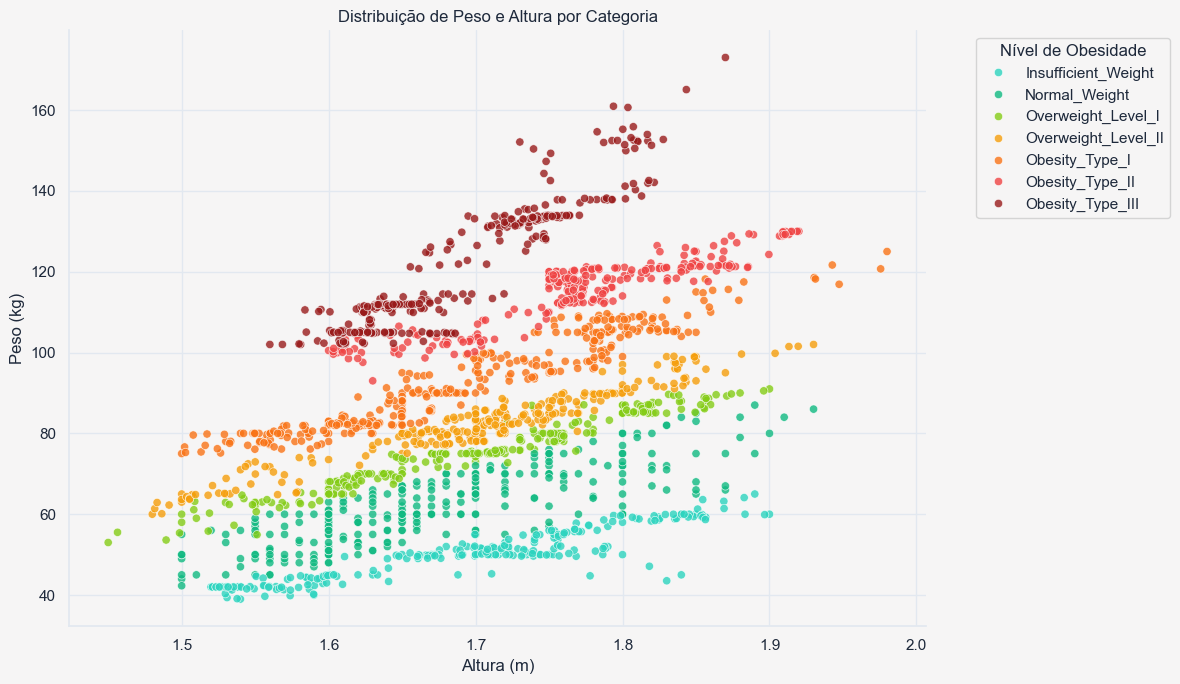

In [102]:
# Ordem lógica dos níveis (abaixo do peso a obesidade tipo III)
ordem_niveis = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_eda,
    x='altura',
    y='peso',
    hue='nivel_obesidade',
    hue_order=ordem_niveis,
    palette=lista_cores_saude,
    alpha=0.8,
    edgecolor='w'
)

plt.title("Distribuição de Peso e Altura por Categoria")

plt.xlabel("Altura (m)")

plt.ylabel("Peso (kg)")

#Ajuste da legenda
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Nível de Obesidade')

plt.savefig("../reports/figures/distribuição_peso_altura_categoria.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- A categorização de nível de obesidade parecer ser bem demarcada, com poucas sobreposições, mais facilmente observadas entre 'Obesity_Type_II' e 'Obesity_Type_III'.

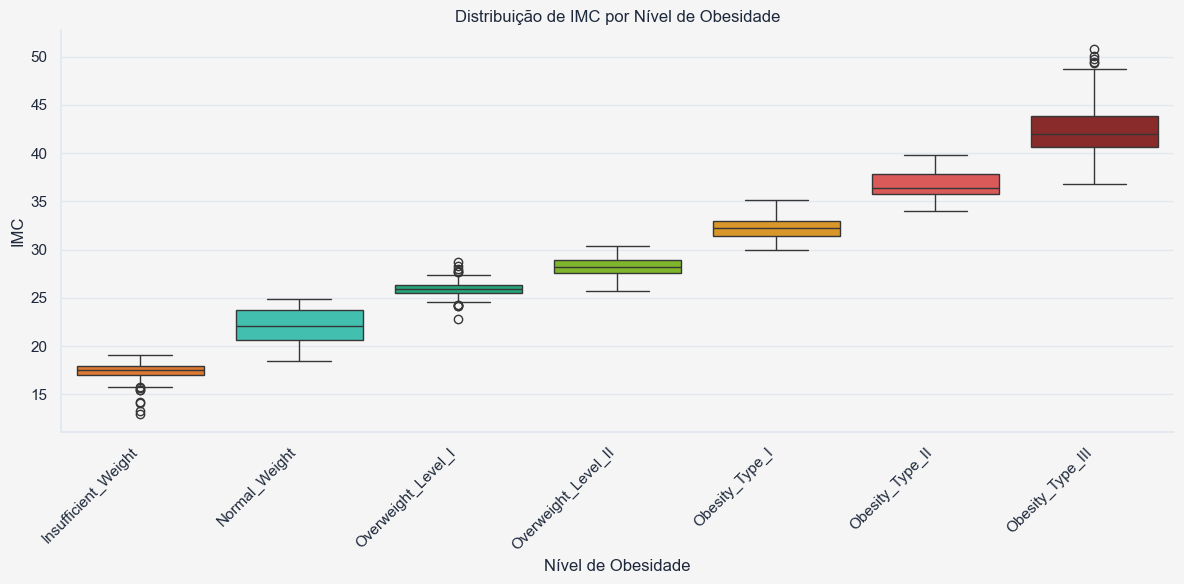

In [103]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_eda,
    x="nivel_obesidade",
    y="IMC",
    order=ordem_niveis,
    hue="nivel_obesidade"
)

plt.title("Distribuição de IMC por Nível de Obesidade")
plt.xlabel("Nível de Obesidade")
plt.ylabel("IMC")
plt.xticks(rotation=45, ha="right")

plt.savefig("../reports/figures/distribuição_IMC_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- O boxplot mostra uma relação fortemente crescente entre o IMC e os níveis de obesidade. As medianas aumentam progressivamente de `Insufficient Weight` até `Obesity Type III`, indicando que o IMC possui alto poder discriminativo para separar as classes da variável alvo.

- Como o nível de obesidade é fortemente relacionado ao IMC, utilizar essa variável como preditora pode tornar o problema excessivamente simples e gerar uma avaliação otimista do modelo.

- Dessa forma, o IMC será tratado como uma variável importante para análise exploratória, mas não será utilizado na modelagem, considerando o risco de funcionar como uma proxy direta da variável alvo.

## Distribuição da Variável Alvo

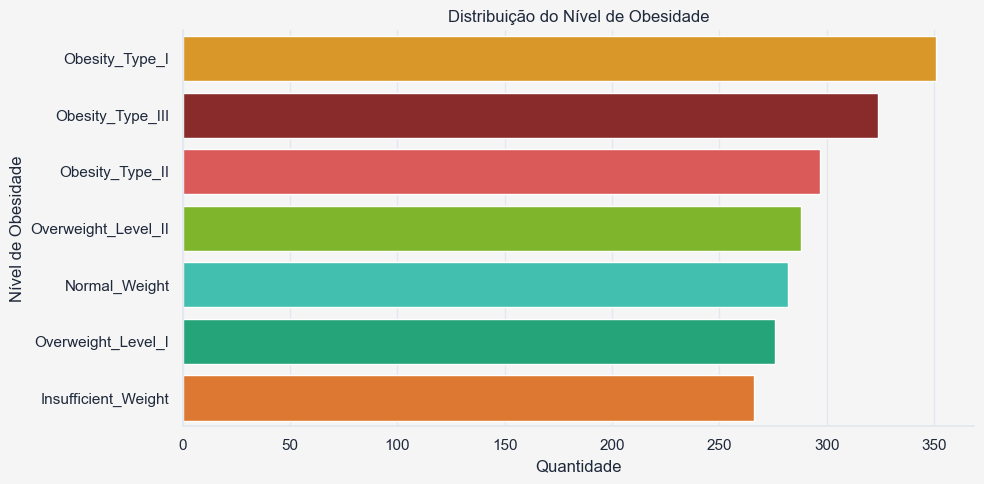

In [104]:
plt.figure(figsize=(10, 5))

order = df_eda["nivel_obesidade"].value_counts().index

sns.countplot(
    data=df_eda,
    y="nivel_obesidade",
    hue="nivel_obesidade",
    order=order
)

plt.title("Distribuição do Nível de Obesidade")
plt.xlabel("Quantidade")
plt.ylabel("Nível de Obesidade")

plt.savefig("../reports/figures/distribuição_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Como a distribuição é relativamente equilibrada, accuracy pode ser usada, mas ainda assim precisamos de F1-score e matriz de confusão.

## Análise da Relação entre Idade e Nível de Obesidade

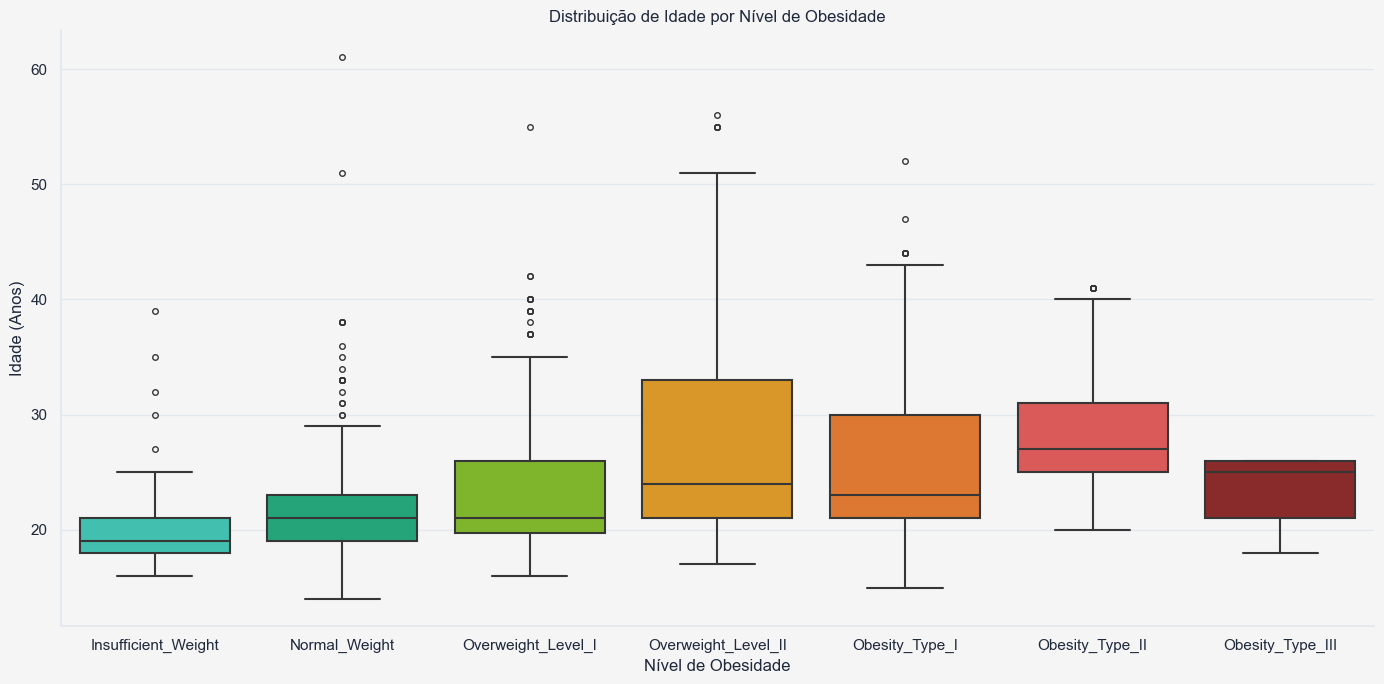

In [105]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_eda,
    x='nivel_obesidade',
    y='idade',
    order=ordem_niveis,
    palette=lista_cores_saude,
    linewidth=1.5,
    fliersize=4 #Tamanho dos pontos de outliers
)

plt.title('Distribuição de Idade por Nível de Obesidade')
plt.xlabel('Nível de Obesidade')
plt.ylabel('Idade (Anos)')

plt.savefig("../reports/figures/distribuição_idade_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- A distribuição de idade entre as categorias de nível de obesidade aponta para o que foi percebido nos dados de estatística descritiva: os dados estão concentrados entre 20 e 25 anos (média 24 anos).

- A categoria Overweight_Level_II tem a caixa e o bigode superior mais altos do que as demais categorias, sugerindo que pessoas acima de 30-35 anos tendem a se concentrar no Sobrepeso Nível II. Pode ser um indicativo de transição metabólica ou mudança de estilo de vida nessa idade.

- A categoria Obesity_Type_III tem uma mediana de idade menor do que a Obesidade Tipo II e um intervalo muito curto. Nessa amostra, o nível mais grave de obesidade ocorre em pessoas muito jovens, entre ~21 e 27 anos.

- Existem muitos pontos acima das caixas entre as categorias de Insufficient_Weight e Overweight_Level_1, o que significa que pacientes com idade acima de 40 anos existem na base, mas eles são a exceção.

- Por fim, a idade não parece ser um fator determinante para a categorização do nível de obesidade, dado que se mantém num intervalo bem justo e próximo em todas as caixas.

## Análise da Relação de Histórico Familiar e Nível de Obesidade

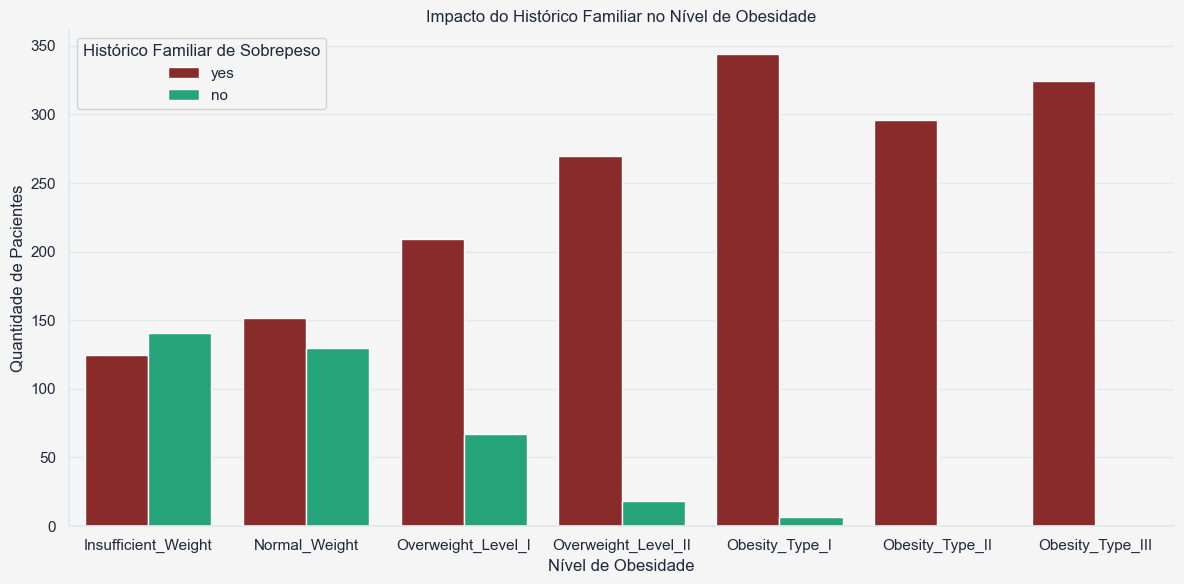

In [106]:
plt.figure(figsize=(12, 6))

# Criando uma contagem proporcional
sns.countplot(data=df_eda, 
              x='nivel_obesidade', 
              hue='historico_familia_sobrepeso', 
              order=ordem_niveis, palette=[paleta['cor_7'], paleta['cor_2']]
             )

plt.title('Impacto do Histórico Familiar no Nível de Obesidade')
plt.xlabel('Nível de Obesidade')
plt.ylabel('Quantidade de Pacientes')

plt.legend(title='Histórico Familiar de Sobrepeso')

plt.savefig("../reports/figures/hist_familiar_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Nota-se que conforme a classificação em nível de obesidade "aumenta", a quantidade de pacientes sem histórico familiar reduz, até se tornar zero nos tipos II e III. Esse comportamento demonstra uma forte relação entre esse o histórico familiar e categorização.

## Atividade Física por Nível de Obesidade

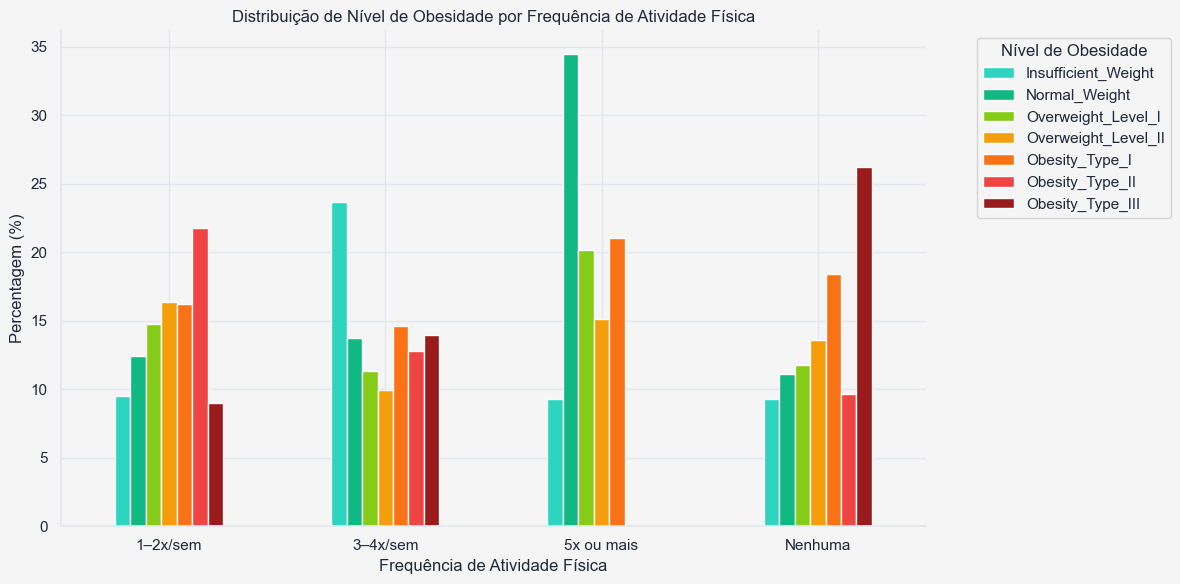

In [107]:
freq_exercicios_obesity = (
    pd.crosstab(
        df_eda["freq_exercicios"],
        df_eda["nivel_obesidade"],
        normalize="index"
    ) * 100
)

freq_exercicios_obesity = freq_exercicios_obesity[ordem_niveis]

freq_exercicios_obesity.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribuição de Nível de Obesidade por Frequência de Atividade Física")
plt.xlabel("Frequência de Atividade Física")
plt.ylabel("Percentagem (%)")

plt.xticks(rotation=0)
plt.legend(title="Nível de Obesidade", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig("../reports/figures/distribuição_atividade_fisica_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Os indivíduos que praticam atividade física 5 vezes ou mais por semana apresentam maior concentração na classe `Normal_Weight`, indicando uma possível associação entre maior frequência de exercício e níveis mais saudáveis de peso.

- Por outro lado, a categoria `Nenhuma` apresenta maior presença relativa de `Obesity_Type_III`, sugerindo associação entre ausência de atividade física e níveis mais severos de obesidade.

- Entretanto, a relação não é perfeitamente linear. Nas categorias intermediárias, como `1–2x/sem` e `3–4x/sem`, há distribuição entre diferentes níveis de obesidade, indicando que a atividade física isoladamente não explica todo o comportamento da variável alvo.

- Assim, a frequência de atividade física parece ser uma variável relevante para a análise e potencialmente útil para a modelagem.

## Tempo de Tela por Nível de Obesidade

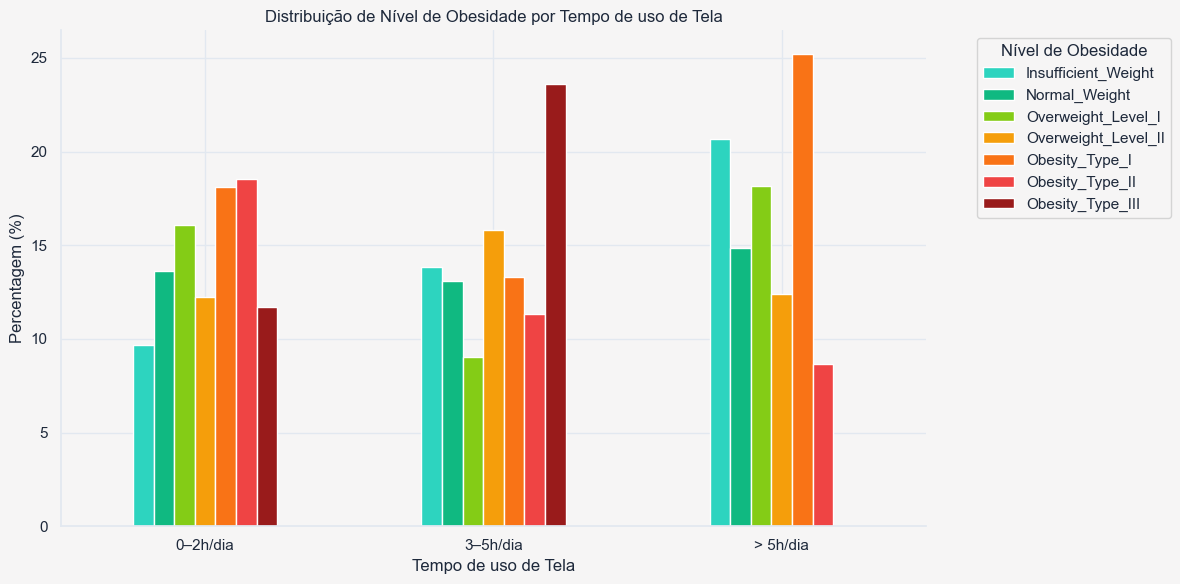

In [108]:
tela_obesidade = (
    pd.crosstab(
        df_eda["tempo_dispositivos_eletronicos"],
        df_eda["nivel_obesidade"],
        normalize="index"
    ) * 100
)

tela_obesidade = tela_obesidade[ordem_niveis]

tela_obesidade.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribuição de Nível de Obesidade por Tempo de uso de Tela")
plt.xlabel("Tempo de uso de Tela")
plt.ylabel("Percentagem (%)")

plt.xticks(rotation=0)
plt.legend(title="Nível de Obesidade", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig("../reports/figures/distribuição_tela_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Diferentemente de variáveis como IMC, consumo frequente de alimentos calóricos e atividade física, o tempo de tela não apresenta uma relação claramente linear com os níveis de obesidade.

- Na faixa de `3–5h/dia`, observa-se maior presença relativa da classe `Obesity_Type_III`, sugerindo uma possível associação entre maior exposição a telas e obesidade severa. No entanto, na faixa `> 5h/dia`, a distribuição também apresenta concentração em classes como `Insufficient_Weight`, `Overweight_Level_I` e `Obesity_Type_I`, o que enfraquece uma interpretação direta.

- Portanto, o tempo de tela pode ser considerado uma variável comportamental potencialmente relevante, mas sua relação com a variável alvo parece menos consistente quando analisada isoladamente.

## Relação entre Tempo Diário Utilizando Dispositivos Eletrônicos e Frequência de Exercícios Físicos

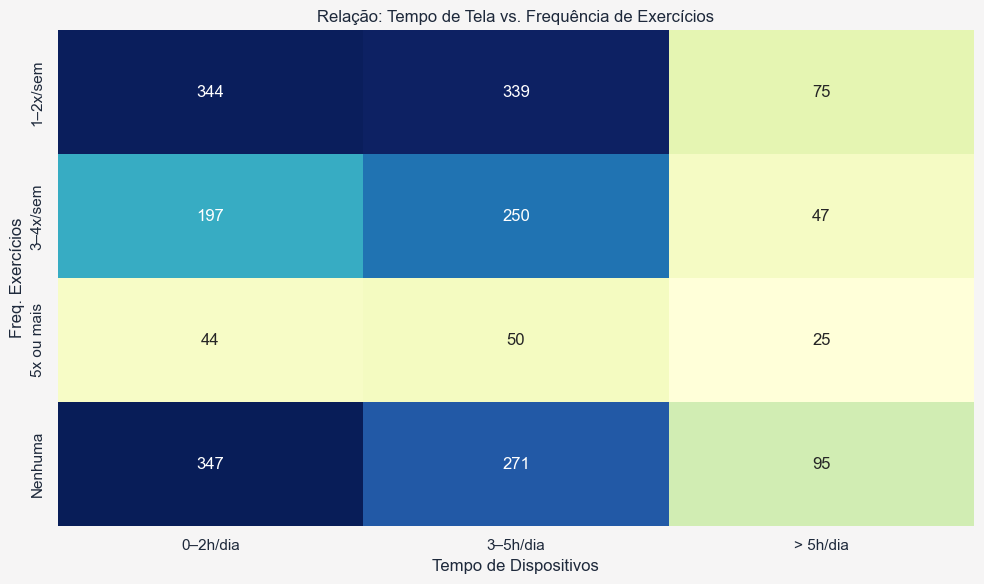

In [109]:
# Criando uma tabela cruzada para o Heatmap
pivot_habitos = df_eda.groupby(['freq_exercicios', 'tempo_dispositivos_eletronicos']).size().unstack()

plt.figure(figsize=(10, 6))

sns.heatmap(pivot_habitos, 
            annot=True, 
            fmt='d', 
            cmap='YlGnBu', 
            cbar=False
           )

plt.title('Relação: Tempo de Tela vs. Frequência de Exercícios')
plt.xlabel('Tempo de Dispositivos')
plt.ylabel('Freq. Exercícios')

plt.savefig("../reports/figures/relação_tela_exercicio.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- A maior parte da amostra consome uma quantidade moderada de tela (até 5h/dia) e ainda consegue praticar exercícios 1-2x por semana (que é onde está a maior concentração de pessoas). Isso mostra que o uso de dispositivos não impede totalmente a atividade física, mas a limita a uma frequência baixa.

- Existe uma grande concentração de pessoas que praticam nenhum ou exercício de 1-2x/semana e usam até 2h de tela por dia, o que sugere pouca ou nenhuma relação do uso de dispositivos eletrônicos com a baixa frequência de exercícios. Além disso, proporcionalmente, quem usa muita tela tem uma chance bem menor de estar nos grupos de exercícios frequentes (3-4x ou 5x ou mais).

- Este gráfico mostra que as variáveis tempo_dispositivos_eletronicos e freq_exercicios estão bem distribuídas, mas não parecem ter uma correlação linear perfeita (onde mais tela significaria necessariamente zero exercício).

## Relação entre o Meio de Transporte e o Peso

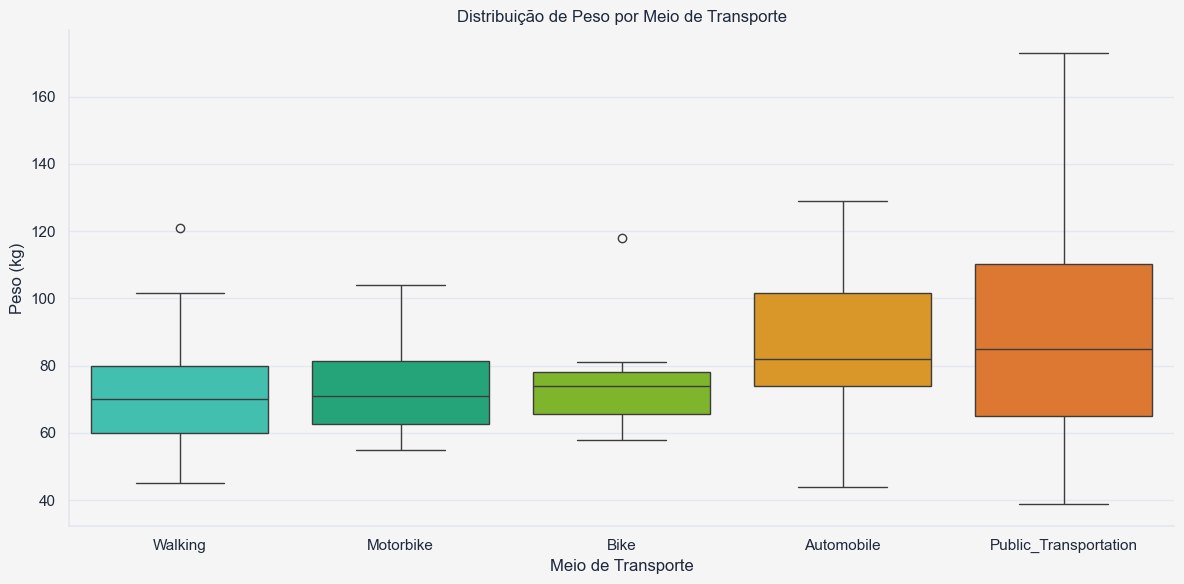

In [110]:
plt.figure(figsize=(12, 6))

#Ordenando do meio mais ativo para o menos ativo para melhor leitura
ordem_transporte = df_eda.groupby('meio_transporte')['peso'].median().sort_values().index

sns.boxplot(data=df_eda, 
            x='meio_transporte', 
            y='peso', 
            palette=lista_cores_saude, 
            order=ordem_transporte
           )

plt.title('Distribuição de Peso por Meio de Transporte')
plt.xlabel('Meio de Transporte')
plt.ylabel('Peso (kg)')

plt.savefig("../reports/figures/distribuição_peso_transporte.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Existe uma divisão no gráfico, entre a pé (Walking), moto (Motorbike) e bicicleta (Bike), com medianas de peso abaixo de 80 kg e caixas mais compactas; e usuários de carro (Automobile) e transporte público (Public_Transportation), com as maiores medianas e uma dispersão de peso muito maior.

- A categoria Public_Transportation apresenta a maior variabilidade de todas e também onde encontramos o maior peso da base (próximo a 180kg). Isso sugere que o transporte público, embora envolva caminhar até a estação e baldeações, é o meio utilizado pela maior diversidade de pessoas.

- O uso da bicicleta parece ser o hábito mais consistente para manter o peso em faixas menores nesta amostra (com exceção de um único outlier), pois sua caixa é "achatada" e tem a menor mediana visual.

## Meio de Transporte vs Obesidade

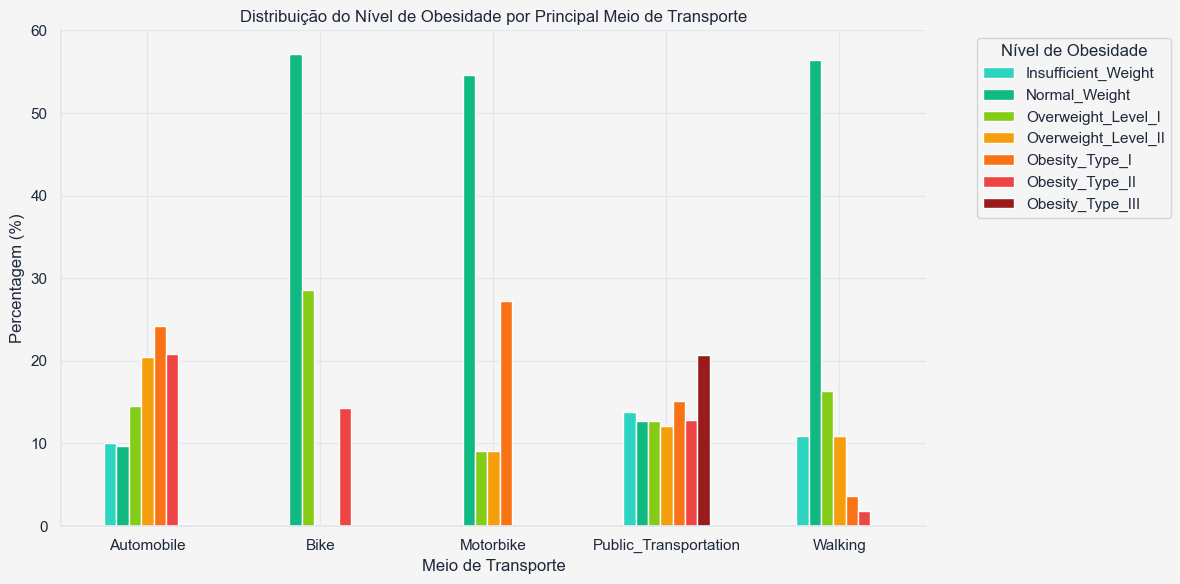

In [111]:
mtrans_obesidade = (
    pd.crosstab(
        df_eda["meio_transporte"],
        df_eda["nivel_obesidade"],
        normalize="index"
    ) * 100
)

mtrans_obesidade = mtrans_obesidade[ordem_niveis]

mtrans_obesidade.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribuição do Nível de Obesidade por Principal Meio de Transporte")
plt.xlabel("Meio de Transporte")
plt.ylabel("Percentagem (%)")

plt.legend(title="Nível de Obesidade", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)

plt.savefig("../reports/figures/distribuição_transporte_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

Meios de transporte mais ativos, como `Walking` e `Bike`, apresentam maior concentração de indivíduos na classe `Normal_Weight`, sugerindo uma possível associação entre deslocamento ativo e níveis mais saudáveis de peso.

Por outro lado, o uso de `Automobile` apresenta maior presença relativa de classes associadas à obesidade, especialmente `Obesity_Type_I` e `Obesity_Type_II`. A categoria `Public_Transportation` também apresenta destaque para `Obesity_Type_III`, embora essa relação deva ser interpretada com cautela, pois pode estar associada a outros fatores comportamentais, sociais ou de rotina.

Assim, o principal meio de transporte parece ser uma variável comportamental relevante para a análise, mas não deve ser interpretado de forma causal. 

## Lanches/petiscos entre Refeições e a Obesidade

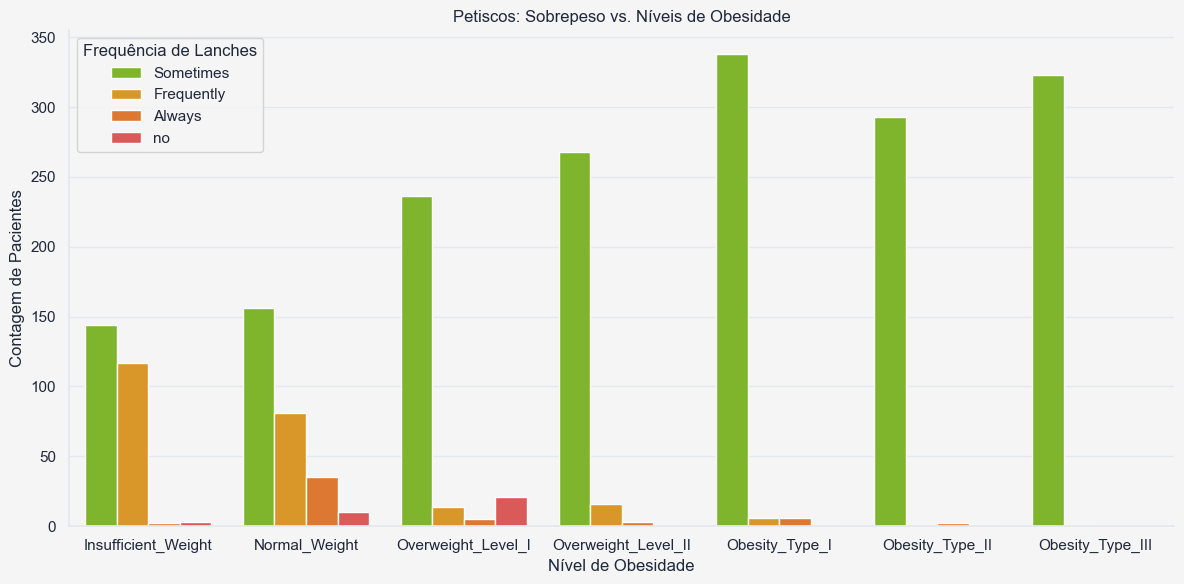

In [112]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df_eda, 
              x='nivel_obesidade', 
              hue='consumo_lanches_entre_refeicoes',
              palette=lista_cores_saude[2:6], 
              order=ordem_niveis
             )

plt.title('Petiscos: Sobrepeso vs. Níveis de Obesidade')
plt.xlabel('Nível de Obesidade')
plt.ylabel('Contagem de Pacientes')

plt.legend(title='Frequência de Lanches')

plt.xticks(rotation=0)

plt.savefig("../reports/figures/distribuição_petiscos_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- O gráfico demonstra que, de forma geral, não existem comportamentos binários de sempre ou nunca petiscar. Pessoas em peso normal (Normal_Weight) parecem ter a maior diversidade de frequência dos petiscos. Em todas as categorias, 'às vezes' (Sometimes) aparece em maior frequência. Este não parece ser um bom indicador de obesidade ou sobrepeso, já que não há um comportamento mais bem demarcado entre as categorias.

## Monitoramento de Calorias

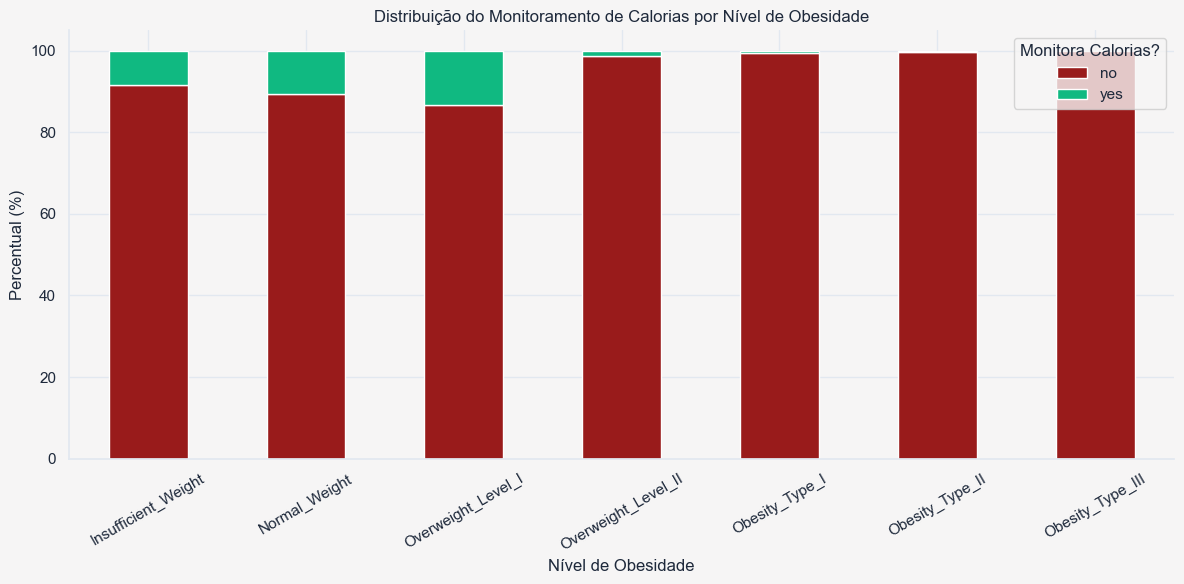

In [113]:
# Criando uma tabela cruzada normalizada
tab_monitoramento = pd.crosstab(df_eda['nivel_obesidade'], df_eda['monitora_calorias_dia'], normalize='index') * 100

tab_monitoramento = tab_monitoramento.reindex(ordem_niveis)

ax = tab_monitoramento.plot(kind='bar', 
                            stacked=True, 
                            figsize=(12, 6),
                            color=[paleta['cor_7'], paleta['cor_2']]
                           )

plt.title('Distribuição do Monitoramento de Calorias por Nível de Obesidade')
plt.xlabel('Nível de Obesidade')
plt.ylabel('Percentual (%)')

plt.legend(title="Monitora Calorias?", loc='upper right')

plt.xticks(rotation=30)

plt.savefig("../reports/figures/distribuição_calorias_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Nota-se que, na amostra, pacientes que realizam o monitoramento calórico representam a menor parte, sendo pouco mais relevante com pouco mais de 10% dos pacientes na categoria de sobrepeso nível I (Overweight_Level_I). Fato é que o monitoramento em todas as categorias de obesidade é praticamente inexistente, o que pode ser um bom partidor para classificação.

## Consumo de Alimentos Calóricos vs Obesidade

In [114]:
cvo_obesity = (
    pd.crosstab(
        df_eda["freq_alimentos_caloricos"],
        df_eda["nivel_obesidade"],
        normalize="index"
    ) * 100
)
cvo_obesity = cvo_obesity[ordem_niveis]
cvo_obesity

nivel_obesidade,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
freq_alimentos_caloricos,,,,,,,
no,20.5761,32.0988,9.0535,30.4527,4.5267,2.8807,0.4115
yes,11.7328,11.0809,13.7968,11.6241,18.4682,15.7523,17.5448


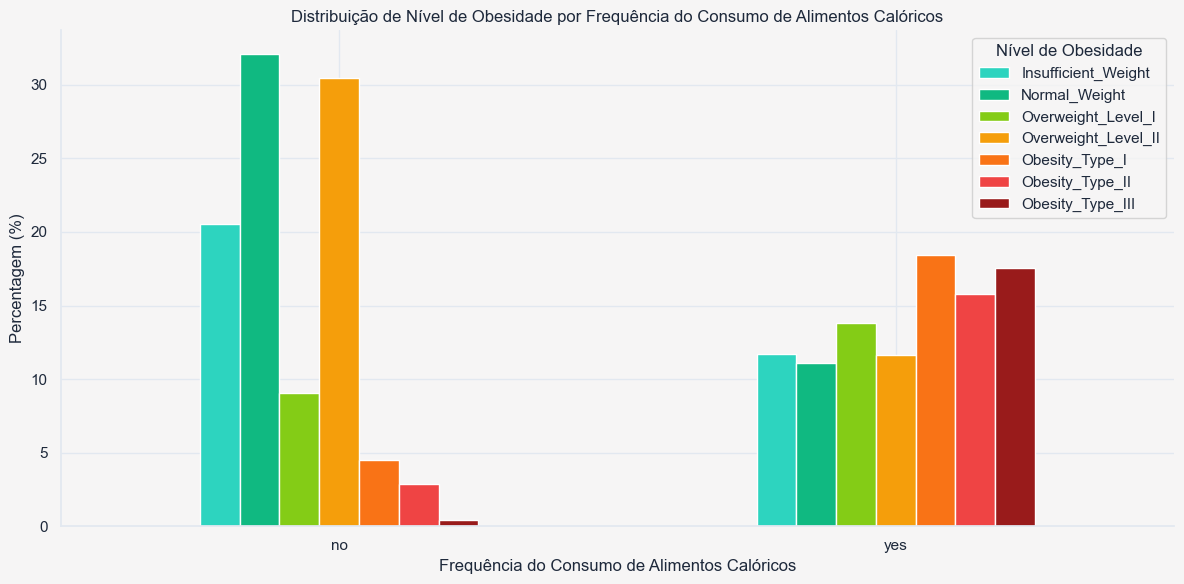

In [115]:
cvo_obesity.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribuição de Nível de Obesidade por Frequência do Consumo de Alimentos Calóricos")
plt.xlabel("Frequência do Consumo de Alimentos Calóricos")
plt.ylabel("Percentagem (%)")

plt.xticks(rotation=0)

plt.legend(title="Nível de Obesidade")

plt.savefig("../reports/figures/distribuição_alimetos_caloricos_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Entre os indivíduos que responderam “yes”, há maior presença das classes associadas à obesidade, especialmente `Obesity_Type_I`, `Obesity_Type_II` e `Obesity_Type_III`.

- Por outro lado, entre os indivíduos que responderam “no”, as maiores concentrações aparecem em classes como `Normal_Weight`, `Insufficient_Weight` e algumas categorias de sobrepeso.

- Esse comportamento sugere que o consumo frequente de alimentos calóricos pode ser uma variável relevante para o modelo preditivo, pois apresenta associação com níveis mais elevados de obesidade. No entanto, essa relação deve ser interpretada como associação estatística, e não como causalidade direta.

## Diferença entre Gêneros

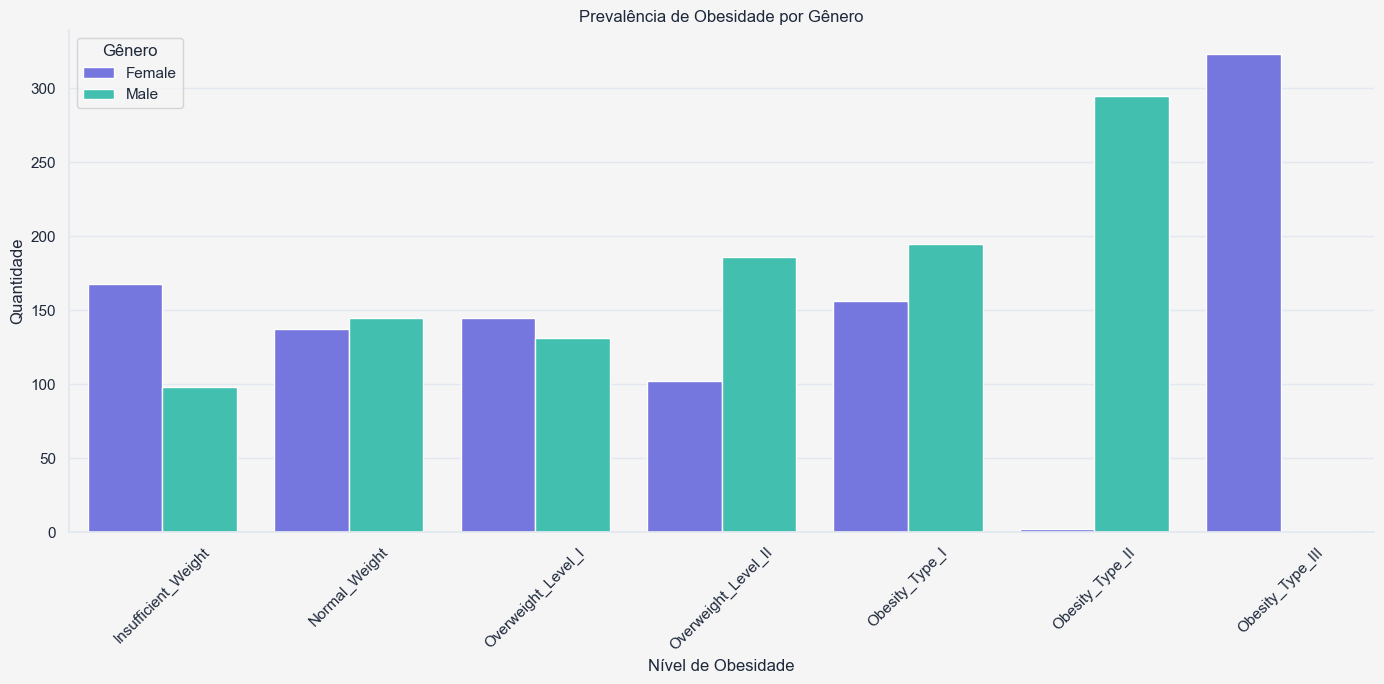

In [116]:
plt.figure(figsize=(14, 7))

#Gráfico de contagem dividida por Gênero
sns.countplot(data=df_eda, 
              x='nivel_obesidade', 
              hue='genero',
              palette=[paleta['extra'], paleta['cor_1']],
              order=ordem_niveis
             )

plt.title('Prevalência de Obesidade por Gênero')
plt.xlabel('Nível de Obesidade')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.legend(title="Gênero")

plt.savefig("../reports/figures/distribuição_genero_obesidade.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.tight_layout()
plt.show()

- Existe uma categorização muito importante nos dois casos mais graves de obesidade; Obesity_Type_II, composta quase exclusivamente por homens (Male) na amostra; Obesity_Type_III, composta exclusivamente por mulheres (Female) na amostra.

- Isso pode demonstrar que de fato existe uma segregação clara de gênero nas classificações mais graves de obesidade ou que faltam amostras de pacientes de genêros mais variados nessas categorias.

- Nas categorias Normal_Weight e Overweight_Level_I, há um equilíbrio quase perfeito entre os gêneros. Isso indica que, até o início do sobrepeso, o comportamento da amostra não distingue homens de mulheres.

- Os homens (Male) passam a se destacar numericamente a partir do Overweight_Level_II, sugerindo que o ganho de peso masculino nesta amostra tende a progredir de forma mais acentuada para o nível II de sobrepeso e nível I de obesidade.

- Mulheres (Female) tem maior prevalência de baixo peso.

## Hipóteses Analíticas Iniciais

1. Espera-se que as variáveis de perfil corporal sejam os preditores mais fortes.

- O uso destas variáveis como preditoras pode simplificar excessivamente a tarefa de classificação e levar a uma estimativa de desempenho superior àquela esperada em um cenário mais realista.
- Por esse motivo, elas não serão incluídas na etapa de modelagem, devido ao risco de atuar como uma proxy direta da variável alvo.

2. O histórico familiar pode estar associado a níveis mais elevados de obesidade.

- Pacientes com histórico familiar de sobrepeso podem apresentar maior concentração em níveis relacionados à obesidade.

3. O consumo frequente de alimentos hipercalóricos pode estar associado a níveis mais elevados de obesidade.

- Essa variável pode ajudar a identificar padrões de risco relacionados ao estilo de vida.

4. A frequência da atividade física pode ajudar a diferenciar os níveis de obesidade.

- Níveis mais baixos de atividade podem estar associados a categorias de obesidade mais elevadas.

5. O tempo de uso de tecnologia pode servir como um indicador de comportamento sedentário.

- No entanto, isso deve ser interpretado com cautela e não como um fator causal.

6. A combinação entre tempo de tela e baixa atividade física pode ser mais relevante do que cada variável separadamente.

- O comportamento sedentário pode estar melhor representado pela interação entre tempo de tela e frequência de exercícios.
- Essa combinação pode ajudar a identificar perfis de maior risco.

7. O meio de transporte pode fornecer contexto comportamental.

- Caminhar ou andar de bicicleta podem estar associados a diferentes distribuições de obesidade em comparação com o uso de automóvel ou transporte público.

8. A frequência de petiscos pode não apresentar relação linear clara com obesidade.

- A categoria “Sometimes” aparece com frequência elevada em diferentes níveis de obesidade.
- Isso sugere que a variável pode não diferenciar bem as classes quando analisada isoladamente.

9. O monitoramento de calorias pode ter baixo poder explicativo isoladamente.

- A maioria dos pacientes parece não monitorar calorias, independentemente do nível de obesidade.
- Essa variável pode ser mais útil quando analisada em conjunto com outros hábitos alimentares e comportamentais.

10. O gênero pode estar fortemente associado às categorias mais severas de obesidade

- A distribuição sugere uma separação forte entre homens e mulheres em algumas classes mais graves.
- Essa hipótese deve ser analisada com cautela, pois pode indicar padrão da amostra, viés nos dados ou baixa representatividade em determinadas categorias.

11. Algumas variáveis comportamentais podem ter poder preditivo limitado de forma isolada.

- Tempo de tela, frequência de petiscos e monitoramento de calorias parecem apresentar padrões menos claros.
- Essas variáveis podem contribuir melhor para o modelo quando combinadas com outras informações.

12. Alguns padrões podem refletir características específicas da amostra.

- Distribuições muito marcadas, como a separação por gênero em certas classes, podem estar relacionadas à forma como os dados foram coletados ou organizados.
- Por isso, as conclusões da EDA devem ser tratadas como associações exploratórias, e não como evidências clínicas definitivas.